In [1]:
from pathlib import Path
import io
from itertools import islice
from typing import Iterator

from PIL import Image


here = Path().resolve() 

ocr_dir = here / "ocr"
data_dir = ocr_dir / "data"
im2latex_dir = data_dir / "im2latex-230k" / "PRINTED_TEX_230k"
png_dir = im2latex_dir / "generated_png_images"

R _ { 1 2 } K _ { 1 } R _ { 2 1 } d K _ { 2 } = d K _ { 2 } R _ { 1 2 } K _ { 1 } R _ { 1 2 } ^ { - 1 } ,


E _ { n } - E _ { m } = \frac { \lambda ^ { \prime } ( n ^ { 2 } y ^ { 2 } - m ^ { 2 } ) } { y ^ { 2 } } .


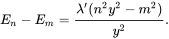

\sigma ^ { 1 } + i \sigma ^ { 2 } = f ( \sigma ^ { 1 } + i \sigma ^ { 2 } )


B | _ { \partial \Sigma _ { 3 } } \rightarrow B | _ { \partial \Sigma _ { 3 } } - \Lambda | _ { \partial \Sigma _ { 3 } } .


\phi _ { i } ^ { \prime } ( x ) = \phi _ { i } ( x ) + \delta _ { \mathrm { B R S } } [ \phi _ { i } ] \Theta [ \phi ]


In [2]:
def lines(txt: io.StringIO) -> Iterator[str]:
    """Lazily yields lines. Closes IO when exhausted."""
    for line in txt:
        yield line.rstrip("\n\r")


def load_pairs(num: int) -> Iterator[tuple[Image.Image, str]]:
    """Loads pairs of pillow Images and their respective LaTeX in the form (Image, LaTeX)"""

    png_map = open(im2latex_dir / "corresponding_png_images.txt", "r")
    png_formulas = open(im2latex_dir / "final_png_formulas.txt", "r")

    try:
        for png, formula, count in zip(lines(png_map), lines(png_formulas), range(num)):
            img = Image.open(png_dir / png)
            yield img, formula

    finally:
        png_map.close()
        png_formulas.close()
    

for img, formula in load_pairs(5):
    print(formula)
    display(img)

In [16]:
"""
Loading data.
"""

from os import PathLike
from typing import Any

from torchvision.io import decode_image


class Im2Latex230kDataset:
    def __init__(
        self,
        root_path: PathLike,
        num: int | None = None,
        transform: Any = None,
        target_transform: Any = None,
    ) -> None:
        self.path = root_path
        self.num = num
        self.transform = transform
        self.target_transform = target_transform

        self.pairs = self._load_pairs(num)

    def __len__(self):

        return len(self.pairs)

    def __getitem__(self, idx: int):
        png_path, formula = self.pairs[idx]
        image = decode_image(png_path)

        if self.transform is not None:
            image = self.transform(image)

        if self.target_transform is not None:
            formula = self.target_transform(image)

        return image, formula

    def _load_pairs(self, num: int | None = None) -> tuple[list[str], list[str]]:
        im2latex_dir = self.path / "PRINTED_TEX_230k"
        png_dir = im2latex_dir / "generated_png_images"

        with open(im2latex_dir / "corresponding_png_images.txt") as png_map:
            png_lines = [line.rstrip("\r\n") for line in png_map.readlines()]
            png_paths = [png_dir / png for png in png_lines]
            if num is not None:
                png_paths = png_paths[:num]

        with open(im2latex_dir / "final_png_formulas.txt") as png_formulas:
            formulas = [line.rstrip("\r\n") for line in png_formulas.readlines()]
            if num is not None:
                formulas = formulas[:num]
        return list(zip(png_paths, formulas))


In [17]:
from torch.utils.data import DataLoader

dataset = Im2Latex230kDataset(data_dir / "im2latex-230k")

In [11]:
Image.open("/home/ykip10/Desktop/personal-projects/pdf2tex/src/ocr/data/im2latex-230k/PRINTED_TEX_230k/generated_png_images/80f1db54ec657ab.png")

In [ ]:
dataloader = DataLoader(dataset)
img, formula = next(iter(dataset))

In [16]:
"""
Building off of: https://arxiv.org/pdf/2010.11929
"""

import torch

from torch import nn
from torch.nn.functional import scaled_dot_product_attention


class MHALayer(nn.Module):
    def __init__(
        self, embed_dim: int, num_heads: int, dropout: bool = False, vdim: int | None = None, kdim: int | None = None
    ):
        """
        Implementation of a standard multi head attention layer.

        Args:
            embed_dim (int): Dimension of input embeddings.
            num_heads (int): Number of attention heads.
            qk_dim (int): Dimension of the query-key vectors.
            dropout (bool): Whether to include dropout, which randomly zeroes some neurons (regularisation).
            vdim (int | None): Dimension of the value embeddings.
            kdim (int | None): Dimension of the key embeddings.
        """
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.dropout = dropout

        if kdim is None:
            self.kdim = embed_dim

        if vdim is None:
            self.vdim = embed_dim

        self.head_dim = embed_dim // num_heads

        self.Wq = nn.Linear(self.embed_dim, self.embed_dim, bias=False)
        self.Wk = nn.Linear(self.kdim, self.embed_dim, bias=False)
        self.Wv = nn.Linear(self.vdim, self.embed_dim, bias=False)

        self.out_proj = nn.Linear(self.embed_dim, self.embed_dim)

    def forward(self, x: torch.Tensor, causal: bool = False):
        """
        Args:
            x (torch.Tensor): Input tensor fo size (batch_size, num_tokens, emb_dim) == (B, N, D).
        """
        try:
            B, N, D = x.shape
        except ValueError as e:
            raise e("Input tensor must be of dimension 3: (batch_size, num_tokens, emb_dim).")

        # All of size (B, N, D)
        query = self.Wq(x)
        key = self.Wk(x)
        value = self.Wv(x)

        # sliced per-head (D -> (num_heads, D_head))
        query = torch.reshape(query, (B, N, self.num_heads, self.head_dim))
        key = torch.reshape(query, (B, N, self.num_heads, self.head_dim))
        value = torch.reshape(query, (B, N, self.num_heads, self.head_dim))

        # Compute attention, concatenate across heads, then output projection
        attn = scaled_dot_product_attention(query, key, value, is_causal=causal)
        attn = torch.reshape(attn, (B, N, D))
        attn = self.out_proj(attn)

        # Apply residual conenction and return
        return x + attn


In [17]:
N, B, D = 4, 5, 16
x = torch.rand(size=(N, B, D))

In [19]:
mha = MHALayer(D, 3)

mha(x)

RuntimeError: shape '[4, 5, 3, 5]' is invalid for input of size 320

In [ ]:
from torch.nn import MultiheadAttention

In [1]:
from torchvision.ops import MLP

In [2]:
mlp = MLP(8, [4])

In [6]:
import torch
x = torch.ones(size=(8, ))
x

tensor([1., 1., 1., 1., 1., 1., 1., 1.])

In [9]:
with torch.no_grad():
    y=mlp(x)
y

tensor([ 0.9538, -1.1593,  0.0457,  0.2183])

In [58]:
from typing import Callable, Any

import torch
import torch.nn.functional as F

from msgspec import Struct
from msgspec.structs import asdict


class BaseConfig(Struct):

    def as_dict(self):
        return asdict(self)


class MHAConfig(BaseConfig):
    """Config for MultiheadAttention blocks."""
    embed_dim: int
    num_heads: int
    dropout: bool = False
    vdim: int | None = None
    kdim: int | None = None


class MLPConfig(BaseConfig):
    """Config for FFN layers."""
    hidden_channels: list[int]
    activation_layer: Callable[[torch.Tensor, str], torch.Tensor] = F.gelu
    bias: bool = True
    dropout: float = 0


class NormConfig(BaseConfig):
    """Config for LayerNorm."""
    normalized_shape: int | list | torch.Size


class TransformerBlockConfig(BaseConfig):
    attn: MHAConfig
    mlp: MLPConfig
    norm: NormConfig


class ViTConfig(BaseConfig):
    encoder_cfg: TransformerBlockConfig
    decoder_cfg: TransformerBlockConfig
    num_layers: int

    @property
    def encoder_emb_dim(self):
        return self.encoder_cfg.attn.embed_dim

    @property
    def decoder_emb_dim(self):
        return self.decoder_cfg.attn.embed_dim

In [61]:
enc_atn = MHAConfig(4, 4)
enc_mlp = MLPConfig([8])
enc_norm = NormConfig((4, 2))
tbc = TransformerBlockConfig(enc_atn, enc_mlp, enc_norm)
cfg = ViTConfig(tbc, tbc, 1)

In [ ]:
cfg.encoder_emb_dim